In [4]:
import sys

project_path = '/content/drive/MyDrive/credit_score_project'

if project_path not in sys.path:
    sys.path.append(project_path)

In [5]:
## First mount your drive to get the datasets.
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from matplotlib import colormaps
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import my_module.custom_transformers as cst

sklearn.set_config(transform_output = 'pandas')

In [19]:
Australia_CR = pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets/Australian_CR/australian.dat',delimiter=' ',header=None)
column_names = []
for i in range(1,16):
  column_names.append(f"A{i}")

Australia_CR.columns = column_names
Australia_CR.head()
df = Australia_CR.copy()

In [20]:
cleaned_df = pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets_cleaned/AusCR_cleaned.csv',index_col='Unnamed: 0')

In [21]:
cleaned_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1
686,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0
687,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1
688,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1


Missing Attribute Values:
    37 cases (5%) HAD one or more missing values.  The missing
    values from particular attributes WERE:

    A1:  12
    A2:  12
    A4:   6
    A5:   6
    A6:   9
    A7:   9
    A14: 13
    
    THESE WERE REPLACED BY THE MODE OF THE ATTRIBUTE (CATEGORICAL)
                               MEAN OF THE ATTRIBUTE (CONTINUOUS)

In [22]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    int64  
 1   A2      690 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    int64  
 4   A5      690 non-null    int64  
 5   A6      690 non-null    int64  
 6   A7      690 non-null    float64
 7   A8      690 non-null    int64  
 8   A9      690 non-null    int64  
 9   A10     690 non-null    int64  
 10  A11     690 non-null    int64  
 11  A12     690 non-null    int64  
 12  A13     690 non-null    int64  
 13  A14     690 non-null    int64  
 14  A15     690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB


In [24]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
numerical_cols = ['A2','A3','A7','A10','A13','A14']
categorical_cols = ['A1','A4','A5','A6','A8','A9','A11','A12']
target_col = ['A15']

X= cleaned_df.drop(columns=target_col)
y = cleaned_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state = 42)

print(y_train.sum()/len(y_train))
print(y_test.sum()/len(y_test))


A15    0.445652
dtype: float64
A15    0.442029
dtype: float64


array([[<Axes: title={'center': 'A2'}>, <Axes: title={'center': 'A3'}>],
       [<Axes: title={'center': 'A7'}>, <Axes: title={'center': 'A10'}>],
       [<Axes: title={'center': 'A13'}>, <Axes: title={'center': 'A14'}>]],
      dtype=object)

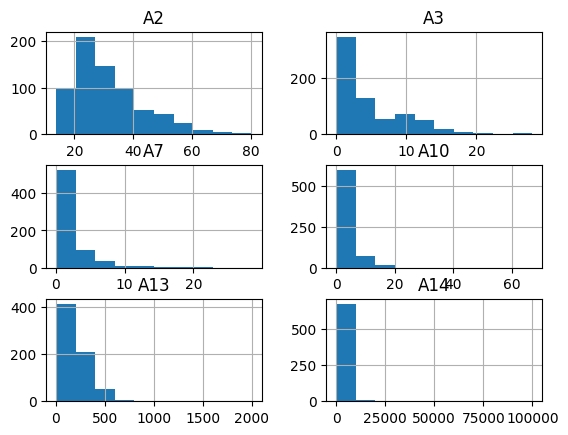

In [27]:
cleaned_df.hist(column=numerical_cols)

# data is right skewed, we may have to use logarithmic transformation later.
# for now we will procced directly then we can appy the transformation and see
# if there are any changes in performance of model. Or sometimes this type of
# transformations can depend on the model that we are going to use. So we will
# make this decision later.


In [28]:
y_train.shape

(552, 1)

In [29]:
col = 'A14'
Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = X_train.loc[(X_train[col] > upper) | (X_train[col] < lower),col]
print(col,len(outliers))
print(outliers)
# From the outliers dataframe, most of the ourliers are form the age column and max
#  value is 74 something which looks alright to me. Not removing the outliers from
#  data cause the higher age can be a signal not a noise in data.

A14 86
166    4209
377    2011
347    2301
52     2101
375    6701
       ... 
20     1005
39     1705
418    5201
458    4501
502    2511
Name: A14, Length: 86, dtype: int64


In [30]:
X_train['A14'].quantile([0,0.25,0.5,0.75,0.85,0.99])

,A14
0.00,1.00
0.25,1.00
0.50,4.00
0.75,348.75
0.85,975.00
0.99,15053.92


In [31]:
class aus_outlier_handle(BaseEstimator, TransformerMixin):
  def __init__(self,columns):
    self.columns = columns

  def fit(self, X, y=None):
    self.upper = {}
    for col in self.columns:
      if col =='A14':
        self.upper[col] = X[col].quantile(0.99)
    return self

  def transform(self, X):
    X = X.copy()
    for col in self.columns:
      X[col] = X[col].clip(upper=self.upper[col])
    return X
outlier_remover = aus_outlier_handle(columns=['A14'])
exdf = outlier_remover.fit_transform(X_train)

15053.920000000002

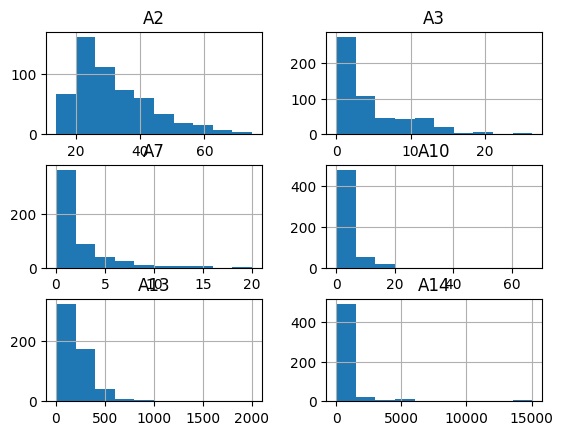

In [32]:
exdf.hist(column=numerical_cols)
exdf['A14'].max()

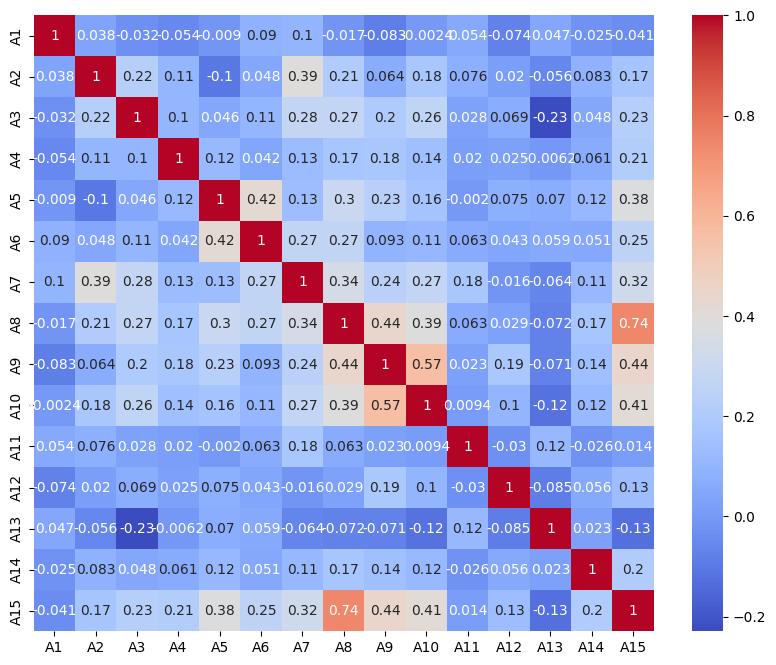

          VIF variables
0   76.382495     const
1    1.282571        A2
2    1.223908        A3
3    1.472591        A7
4    1.608062       A10
5    1.101004       A13
6    1.052986       A14
7    1.041511        A1
8    1.062408        A4
9    1.366319        A5
10   1.330761        A6
11   1.533977        A8
12   1.733466        A9
13   1.057426       A11
14   1.063472       A12


In [33]:


df_corr = pd.concat([X_train,y_train],axis=1)

corr_matrix = df_corr.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.show()

# From the corr matrix we can see that A8 having strong correlation with target
# column. But it is still not that significant so for now no action has been taken

# we also need to check the correlation among the features as well for that we
# will use VIF

X = add_constant(X_train[numerical_cols+categorical_cols])
vif_data = pd.DataFrame()

vif_data['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data['variables'] = X.columns
print(vif_data)

# the values of VIF looks good and are not concerning.

In [34]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [35]:
# There is no preprocessing required for Australian CR data.

In [36]:
# # For the the start we will define cross validation object and
# # will tune logistic regression to see benchmark performance.

# kf = KFold(n_splits=5,shuffle=True,random_state=42)


# logistic_params_random = [
#     {
#         "solver": ["saga"],
#         "penalty": ["elasticnet"],
#         "l1_ratio": [0, 0.25, 0.5, 0.75, 1],
#         "C":[0.01,0.05,0.1,1,10,50,100],
#         "class_weight": ["balanced", None]
#     },
#     {
#         "solver": ["liblinear"],
#         "penalty": ["l1", "l2"],
#         "C":[0.01,0.05,0.1,1,10,50,100],
#         "class_weight": ["balanced", None]
#     },
#     {
#         "solver": ["lbfgs", "newton-cg"],
#         "penalty": ["l2"],
#        "C":[0.01,0.05,0.1,1,10,50,100],
#         "class_weight": ["balanced", None]
#     }
# ]


# aus_lr_r = LogisticRegression(max_iter=50000)


# random_grid = RandomizedSearchCV(aus_lr_r,logistic_params_random,n_iter=10,scoring='f1',cv=kf,verbose=1)
# random_grid.fit(X_train,y_train.values.ravel())

# results = pd.DataFrame(random_grid.cv_results_)
# results.sort_values(by='mean_test_score',ascending=False)


In [37]:
australian_lr_final = LogisticRegression(max_iter=50000,solver='liblinear',penalty='l2',C=100)
australian_lr_final.fit(X_train,y_train.values.ravel())

LogisticRegression(C=100, max_iter=50000, solver='liblinear')

In [38]:
y_pred = australian_lr_final.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test.values.ravel(), y_pred))
print(classification_report(y_test.values.ravel(), y_pred))

[[57 20]
 [ 3 58]]
              precision    recall  f1-score   support

           0       0.95      0.74      0.83        77
           1       0.74      0.95      0.83        61

    accuracy                           0.83       138
   macro avg       0.85      0.85      0.83       138
weighted avg       0.86      0.83      0.83       138



In [39]:
australian_lr_final.get_params()

{'C': 100,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 50000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [40]:
X_train.isnull().sum()

,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0
A10,0


In [6]:
numerical_cols = ['A2','A3','A7','A10','A13','A14']
categorical_cols = ['A1','A4','A5','A6','A8','A9','A11','A12']
target_col = ['A15']
from sklearn.preprocessing import FunctionTransformer
import numpy as np

skew_scaler = ColumnTransformer(transformers=[
      ("skew scaler",FunctionTransformer(func=np.log1p),['A13','A14'])
], remainder='passthrough')


numeric_pipeline = Pipeline(steps=[
    ("outlier handle",cst.aus_outlier_handle(columns=['A14'])),
    ("skew columns", skew_scaler),
    ("std scaler", StandardScaler()),
     ('renamer',cst.renamer())

])
preprocess_pipeline = ColumnTransformer(transformers=[
    ("numeric cols",numeric_pipeline,['A2','A3','A7','A10','A13','A14']),
    ("categorical cols",'passthrough',['A1','A4','A5','A6','A8','A9','A11','A12'])

])

import joblib
joblib.dump(preprocess_pipeline,'/content/drive/MyDrive/credit_score_project/preprocessing/aus_cr_preprocess_v1.joblib')

['/content/drive/MyDrive/credit_score_project/preprocessing/aus_cr_preprocess_v1.joblib']

In [42]:
from sklearn.utils.validation import check_is_fitted
z = check_is_fitted(preprocess_pipeline)

NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
X_train

In [ ]:
preprocess_pipeline

In [ ]:
exdf = preprocess_pipeline.fit_transform(X_train)

In [ ]:
exdf.hist(figsize=(10,10))

In [ ]:
exdf.describe()